In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import time

from tqdm import tqdm

import numpy as np
import pandas as pd

import hyperopt.hp as hp

from sklearn.model_selection import train_test_split

from catboost import CatBoostClassifier

from sklift.datasets import fetch_x5
from sklift.metrics import qini_auc_score, uplift_at_k

# econml
from econml.dml import CausalForestDML

#causalml
from causalml.inference.tree import UpliftRandomForestClassifier

from upninja.dml.UpliftRandomForestDML import UpliftRandomForestDML
from upninja.dml.UpliftTreeClassifierDML import UpliftTreeClassifierDML
from upninja.tune.Selection import UpliftTune

import matplotlib.pyplot as plt
import seaborn as sns

Failed to import duecredit due to No module named 'duecredit'


In [3]:
SEED = 8

In [4]:
%%time

dataset = fetch_x5()
dataset.data.keys()

CPU times: user 23.6 s, sys: 4.25 s, total: 27.9 s
Wall time: 30 s


dict_keys(['clients', 'train', 'purchases'])

In [5]:
%%time

print(f'Dataset type: {type(dataset)}\n')
print(f'Dataset features shape: {dataset.data['clients'].shape}')
print(f'Dataset features shape: {dataset.data['train'].shape}')
print(f'Dataset target shape: {dataset.target.shape}')
print(f'Dataset treatment shape: {dataset.treatment.shape}')

Dataset type: <class 'sklearn.utils._bunch.Bunch'>

Dataset features shape: (400162, 5)
Dataset features shape: (200039, 1)
Dataset target shape: (200039,)
Dataset treatment shape: (200039,)
CPU times: user 79 μs, sys: 114 μs, total: 193 μs
Wall time: 198 μs


In [6]:
%%time

# Извлечение данных
df_clients = dataset.data['clients'].set_index('client_id')
df_train = pd.concat([dataset.data['train'], dataset.treatment , dataset.target], axis=1).set_index('client_id')
indices_test = pd.Index(set(df_clients.index) - set(df_train.index))

# Извлечение признаков
df_features = df_clients.copy()
df_features['first_issue_time'] = \
    (pd.to_datetime(df_features['first_issue_date'])
     - pd.Timestamp('1970-01-01')) // pd.Timedelta('1s')
df_features['first_redeem_time'] = \
    (pd.to_datetime(df_features['first_redeem_date'])
     - pd.Timestamp('1970-01-01')) // pd.Timedelta('1s')
df_features['issue_redeem_delay'] = df_features['first_redeem_time'] \
    - df_features['first_issue_time']
df_features = df_features.drop(['first_issue_date', 'first_redeem_date'], axis=1)

indices_learn, indices_valid = train_test_split(df_train.index, test_size=0.3, random_state=SEED)

CPU times: user 157 ms, sys: 30.1 ms, total: 187 ms
Wall time: 187 ms


In [7]:
%%time

X_train = df_features.loc[indices_learn, :]
y_train = df_train.loc[indices_learn, 'target']
treat_train = df_train.loc[indices_learn, 'treatment_flg']

X_val = df_features.loc[indices_valid, :]
y_val = df_train.loc[indices_valid, 'target']
treat_val =  df_train.loc[indices_valid, 'treatment_flg']

X_train_full = df_features.loc[df_train.index, :]
y_train_full = df_train.loc[:, 'target']
treat_train_full = df_train.loc[:, 'treatment_flg']

X_test = df_features.loc[indices_test, :]

X_train['gender'] = X_train['gender'].map({'F': 0, 'U': -1, 'M': 1})
X_val['gender'] = X_val['gender'].map({'F': 0, 'U': -1, 'M': 1})
X_test['gender'] = X_test['gender'].map({'F': 0, 'U': -1, 'M': 1})

X_train.fillna(-1.0, inplace=True)
X_val.fillna(-1.0, inplace=True)
X_test.fillna(-1.0, inplace=True)

cat_features = ['gender']

CPU times: user 191 ms, sys: 4.56 ms, total: 196 ms
Wall time: 195 ms


In [8]:
def get_bootstrap_samples(data, countSamples):
    ind = np.random.randint(0, len(data) - 1, (countSamples, len(data)))
    samples = np.array(data)[ind]
    return samples, ind

def stat_intervals(stat, alpha):
    boundaries = np.percentile(stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

In [9]:
def stat_intervals_qini(b_samples, b_indexes, model):
    stat = []
    for s, i in tqdm(zip(b_samples, b_indexes)):
        pred = model.predict(X_val.iloc[i])
        q = qini_auc_score(y_true=y_val.iloc[i], uplift=pred, treatment=treat_val.iloc[i])
        stat.append(q)
    return stat_intervals(stat, 0.05), stat

def stat_intervals_qini_causal(b_samples, b_indexes, model):
    stat = []
    for s, i in tqdm(zip(b_samples, b_indexes)):
        pred = model.predict(X_val_np[i])[:, 0]
        q = qini_auc_score(y_true=y_val_np[i], uplift=pred, treatment=treat_val.iloc[i])
        stat.append(q)
    return stat_intervals(stat, 0.05), stat

def stat_intervals_qini_econml(b_samples, b_indexes, model):
    stat = []
    for s, i in tqdm(zip(b_samples, b_indexes)):
        pred = model.effect(X_val.iloc[i])
        q = qini_auc_score(y_true=y_val.iloc[i], uplift=pred, treatment=treat_val.iloc[i])
        stat.append(q)
    return stat_intervals(stat, 0.05), stat

In [10]:
diff_func = lambda uplift_pred_1, uplift_pred_2: qini_auc_score(y_val, uplift_pred_1, treat_val) - qini_auc_score(y_val, uplift_pred_2, treat_val)

def qini_diff_test(qini_1, uplift_1, qini_2, uplift_2, b_samples_count, diff_func=diff_func):
    delta = qini_1 - qini_2
    obs_diff = diff_func(uplift_1, uplift_2)
    if obs_diff >= 0:
        p_two_sided = 2 * (np.sum(delta <= 0) / b_samples_count)
    else:
        p_two_sided = 2 * (np.sum(delta >= 0) / b_samples_count)
    return min(1.0, p_two_sided)

In [11]:
np.random.seed(SEED)

bootstrap_samples, bootstrap_indexes = get_bootstrap_samples(X_val, 1000)

In [12]:
models_results = {
    'approach': [],
    'uplift@30%': [],
    'qini-auc': [],
    'CPU time(minutes)': [],
    '95% qini-auc CI': []
}

# ⭐ EconML

In [13]:
%%time
rf_eml = CausalForestDML(
    n_estimators=50,
    min_samples_split=100,
    max_depth=4,
    subforest_size=2,
    random_state=SEED
)

f_time_start = time.process_time_ns()
rf_eml = rf_eml.fit(Y=y_train, T=treat_train, X=X_train)
f_time_end = time.process_time_ns()

uplift_eml = rf_eml.effect(X_val)

eml_score = uplift_at_k(y_true=y_val, uplift=uplift_eml, treatment=treat_val, strategy='by_group', k=0.3)
eml_score_q = qini_auc_score(y_true=y_val, uplift=uplift_eml, treatment=treat_val)

CPU times: user 4min 14s, sys: 508 ms, total: 4min 15s
Wall time: 4min 7s


In [14]:
models_results['approach'].append('EconML')
models_results['uplift@30%'].append(eml_score)
models_results['qini-auc'].append(eml_score_q)
models_results['CPU time(minutes)'].append((f_time_end - f_time_start) / (1000000000 * 60))

In [15]:
ci, eml_stat_q = stat_intervals_qini_econml(bootstrap_samples, bootstrap_indexes, rf_eml)

models_results['95% qini-auc CI'].append(f'[{ci[0]:.6f}, {ci[1]:.6f}]')

1000it [01:52,  8.85it/s]


# ⭐ CausalML

In [16]:
X_train_np, X_val_np, y_train_np, y_val_np, treat_train_str, treat_val_str = (
    X_train.values, X_val.values,
    y_train.values, y_val.values,
    np.where(treat_train == 1, 'treatment', 'control'),
    np.where(treat_val == 1, 'treatment', 'control')
)

In [17]:
%%time

rf_cm = UpliftRandomForestClassifier(
    n_estimators=50,
    min_samples_leaf=100,
    max_depth=4,
    random_state=SEED,
    control_name='control'
)

f_time_start = time.process_time_ns()
rf_cm.fit(X=X_train_np, treatment=treat_train_str, y=y_train_np)
f_time_end = time.process_time_ns()

uplift_cm = rf_cm.predict(X_val_np).flatten()

cm_score = uplift_at_k(y_true=y_val_np, uplift=uplift_cm, treatment=treat_val, strategy='by_group', k=0.3)
cm_score_q = qini_auc_score(y_true=y_val_np, uplift=uplift_cm, treatment=treat_val)

CPU times: user 12.6 s, sys: 585 ms, total: 13.2 s
Wall time: 6.53 s


In [18]:
models_results['approach'].append('CausalML')
models_results['uplift@30%'].append(cm_score)
models_results['qini-auc'].append(cm_score_q)
models_results['CPU time(minutes)'].append((f_time_end - f_time_start) / (1000000000 * 60))

In [19]:
ci, cm_stat_q = stat_intervals_qini_causal(bootstrap_samples, bootstrap_indexes, rf_cm)

models_results['95% qini-auc CI'].append(f'[{ci[0]:.6f}, {ci[1]:.6f}]')

1000it [47:49,  2.87s/it]


# ⭐UpNinja

In [20]:
%%time

space = {
    'min_samples': hp.uniformint('min_samples', 20, 500),
    'max_depth': hp.uniformint('max_depth', 3, 20),
    'bins': hp.uniformint('bins', 5, 30),
    'min_samples_treatment': hp.uniformint("min_samples_treatment", 10, 100),
    'random_state': SEED
}

dml_tune = UpliftTune(
    uplift_model_class=UpliftTreeClassifierDML,
    data=X_train,
    target=y_train,
    treatment=treat_train,
    space=space,
    verbose=True
)

dml_tuned = dml_tune.tune()['best_params']

100%|███████| 50/50 [00:46<00:00,  1.08trial/s, best loss: -0.06131921146183376]
Optimization completed. Best score: 0.0613
Best parameters: {'bins': 7, 'max_depth': 14, 'min_samples': 205, 'min_samples_treatment': 60, 'random_state': 8}
CPU times: user 45.9 s, sys: 183 ms, total: 46.1 s
Wall time: 46.1 s


In [22]:
%%time

rf_un = UpliftRandomForestDML(
    **dml_tuned,
    n_estimators=50
)

f_time_start = time.process_time_ns()
rf_un.fit(X_train, y_train, treat_train)
f_time_end = time.process_time_ns()

uplift_un = rf_un.predict(X_val)

un_score = uplift_at_k(y_true=y_val, uplift=uplift_un, treatment=treat_val, strategy='by_group', k=0.3)
un_score_q = qini_auc_score(y_true=y_val, uplift=uplift_un, treatment=treat_val)

CPU times: user 5.61 s, sys: 50.7 ms, total: 5.66 s
Wall time: 5.66 s


In [23]:
models_results['approach'].append('UpninjaRF')
models_results['uplift@30%'].append(un_score)
models_results['qini-auc'].append(un_score_q)
models_results['CPU time(minutes)'].append((f_time_end - f_time_start) / (1000000000 * 60))

In [24]:
ci, un_stat_q = stat_intervals_qini(bootstrap_samples, bootstrap_indexes, rf_un)

models_results['95% qini-auc CI'].append(f'[{ci[0]:.6f}, {ci[1]:.6f}]')

1000it [01:52,  8.93it/s]


In [25]:
pd.DataFrame(models_results)

,approach,uplift@30%,qini-auc,CPU time(minutes),95% qini-auc CI
0,EconML,0.077100,0.021568,4.248730,"[0.015977, 0.027276]"
1,CausalML,0.070258,0.015794,0.171197,"[0.010257, 0.021343]"
2,UpninjaRF,0.062438,0.014188,0.092501,"[0.009229, 0.019442]"


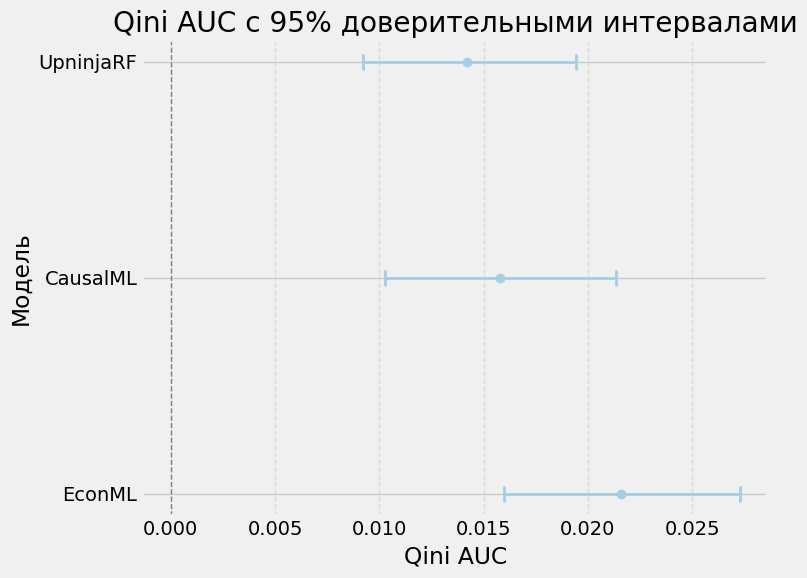

In [27]:
# наложение ДИ друг на друга
models = ['EconML', 'CausalML', 'UpninjaRF']
qini_means = [0.021568, 0.015794, 0.014188]
ci_lower = [0.015977, 0.010257, 0.009229]
ci_upper = [0.027276, 0.021343, 0.019442]

# Ошибки вверх и вниз
error_lower = [mean - low for mean, low in zip(qini_means, ci_lower)]
error_upper = [up - mean for mean, up in zip(qini_means, ci_upper)]

# Горизонтальный график
plt.figure(figsize=(8, 6))
plt.errorbar(qini_means, models, xerr=[error_lower, error_upper], fmt='o', capsize=6, capthick=2, elinewidth=2)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
plt.title('Qini AUC с 95% доверительными интервалами')
plt.xlabel('Qini AUC')
plt.ylabel('Модель')
plt.grid(True, linestyle='--', axis='x', alpha=0.6)
plt.tight_layout()
plt.show()

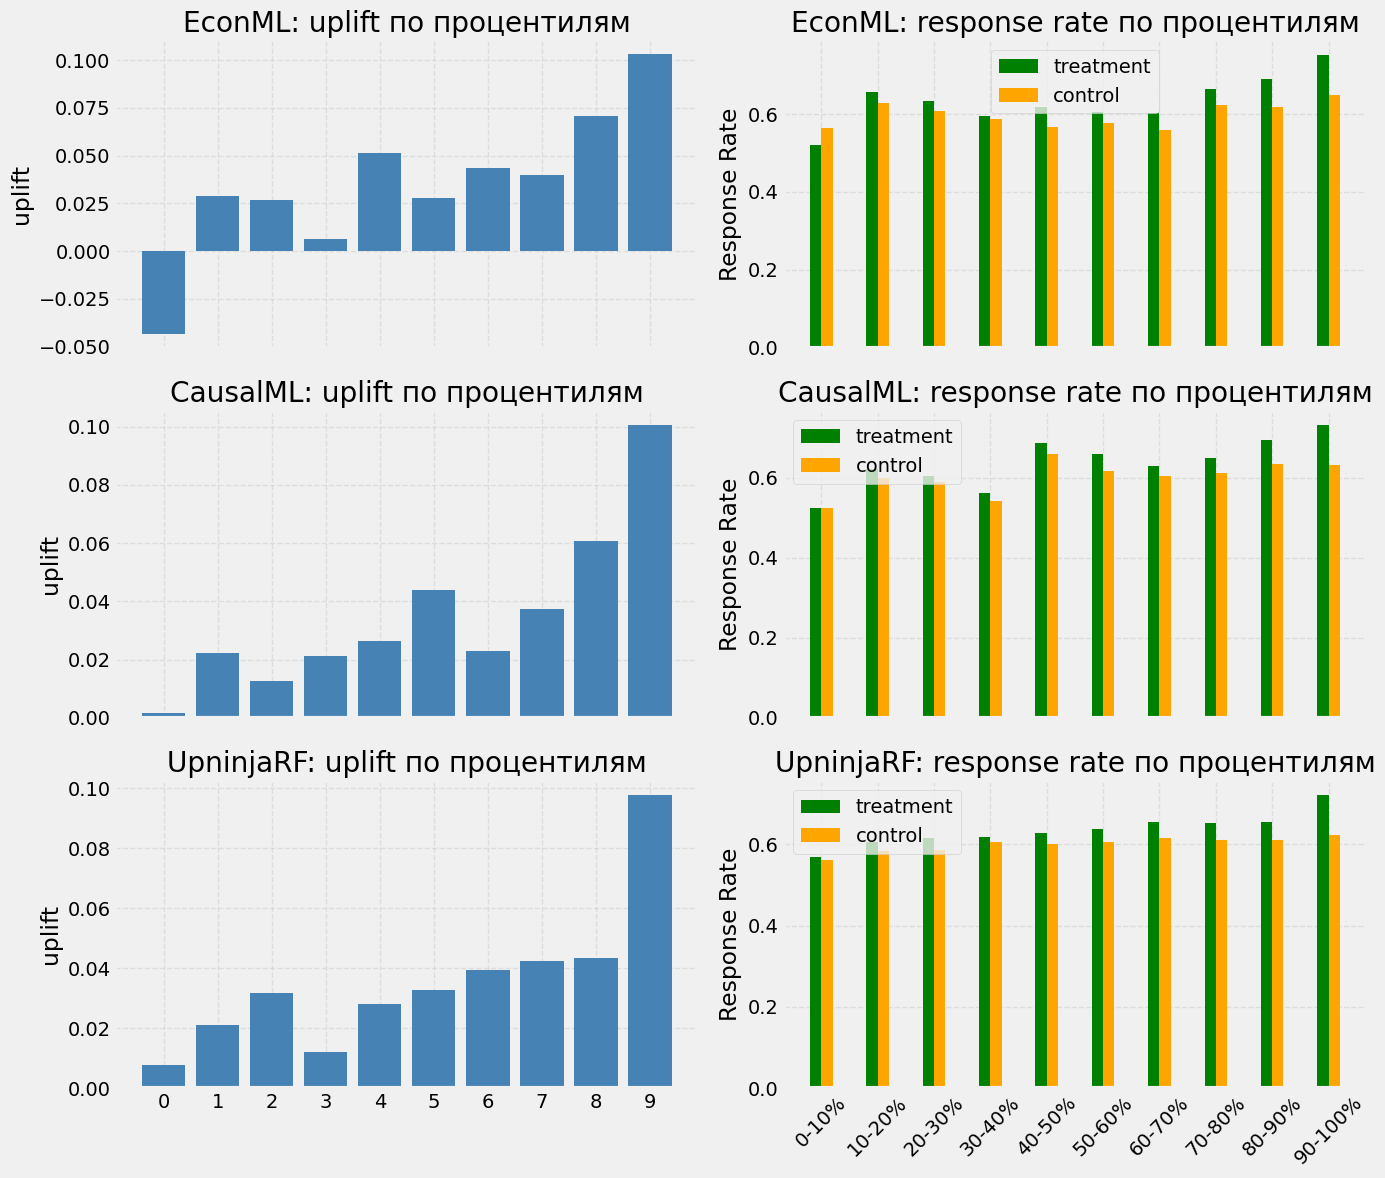

In [28]:
df = pd.DataFrame({
    'treatment': treat_val.values,
    'outcome': y_val.values
})

uplift_scores = {
    'EconML': uplift_eml,
    'CausalML': uplift_cm,
    'UpninjaRF': uplift_un
}

n_bins = 10
percentile_labels = [f"{i*10}-{(i+1)*10}%" for i in range(n_bins)]
x = np.arange(n_bins)

fig, axs = plt.subplots(len(uplift_scores), 2, figsize=(14, 4 * len(uplift_scores)), sharex='col')

for i, (model, scores) in enumerate(uplift_scores.items()):
    df['score'] = scores
    df['percentile'] = pd.qcut(df['score'], q=n_bins, labels=False, duplicates='drop')

    uplift_by_percentile = []
    treat_rates = []
    control_rates = []

    for p in range(n_bins):
        bin_df = df[df['percentile'] == p]
        treated = bin_df[bin_df['treatment'] == 1]['outcome']
        control = bin_df[bin_df['treatment'] == 0]['outcome']
        uplift = treated.mean() - control.mean()
        uplift_by_percentile.append(uplift)
        treat_rates.append(treated.mean())
        control_rates.append(control.mean())

    axs[i, 0].bar(x, uplift_by_percentile, color='steelblue')
    axs[i, 0].set_title(f"{model}: uplift по процентилям")
    axs[i, 0].set_ylabel("uplift")
    axs[i, 0].grid(True, linestyle='--', alpha=0.5)

    axs[i, 1].bar(x - 0.1, treat_rates, width=0.2, label='treatment', color='green')
    axs[i, 1].bar(x + 0.1, control_rates, width=0.2, label='control', color='orange')
    axs[i, 1].set_title(f"{model}: response rate по процентилям")
    axs[i, 1].set_ylabel("Response Rate")
    axs[i, 1].grid(True, linestyle='--', alpha=0.5)
    axs[i, 1].legend()

for ax in axs[:, 1]:
    ax.set_xticks(x)
    ax.set_xticklabels(percentile_labels, rotation=45)
for ax in axs[:, 0]:
    ax.set_xticks(x)

plt.tight_layout()
plt.show()

In [30]:
models = {'EconML': [uplift_eml, eml_stat_q],
          'CausalML': [uplift_cm, cm_stat_q],
          'UpninjaRF': [uplift_un, un_stat_q]}

p_values = pd.DataFrame(np.zeros((3, 3)), columns=models.keys(), index=models.keys())

for model_1 in models.keys():
    for model_2 in models.keys():
        qini_1 = np.array(models[model_1][1])
        uplift_1 = models[model_1][0]
        qini_2 = np.array(models[model_2][1])
        uplift_2 = models[model_2][0]
        p_value = qini_diff_test(qini_1, uplift_1, qini_2, uplift_2, 1000)
        p_values.loc[model_1, model_2] = p_value

<b>Описание теста и его интерпретация</b>:<br>
<b>$H_0:$</b> Модель A и модель B имеют равные значения qini-auc(разница qini-auc-a и qini-auc-b = 0);<br>
<b>$H_1:$</b> Модель A и модель B имеют различные значения qini-auc(разница qini-auc-a и qini-auc-b != 0);<br>

Распределения qini-auc получаются на бутстрапированных выборках. p-value будем аппроксимировать так:<br>
Будем брать долю бутстрап-итераций, в которых знак разницы оказался противоположным наблюдаемому. То есть берем и смотрим разницу в qini-auc двух сравниваемых моделей, полученных в результате моделирования - нас интересует знак. Далее смотрим долю разности бутстрап-экспериментов с противоположным знаком, на основе этой доли и считаем двусторонний p-value(эта доля оценивала вероятность случайного преобладания одной модели над другой). Если p-value > $\alpha = 0.05$, то $H_0$ не отвергается.(основано на bootstrap-sign-test)

In [31]:
p_values

,EconML,CausalML,UpninjaRF
EconML,1.000,0.008,0.024
CausalML,0.008,1.000,0.578
UpninjaRF,0.024,0.578,1.000
